### The goal of this project is to create a model that best predicts the age of a fossil given information such as taxon_name, class, and phylum.

## File and Libraries Setup

### Installing external packages

In [ ]:
!pip install xgboost
!pip install tensorflow
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.8/289.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 747.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 156.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.2/225.2 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 99.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 25.6 MB/s eta 0:00:00


### Imports

In [ ]:
# libraries that will help us
import pandas as pd # handles anything to do with the data
import numpy as np # handles numerical content (mean/mode/median)
import matplotlib.pyplot as plt # allows us to display plots/diagrams
import seaborn as sns # allows us to display plots/diagrams (they're preset)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Reading in Dataset

In [ ]:
# Reads data; convienent so you dont have to upload dataset every you open colab notebook
url = 'https://drive.google.com/file/d/15C7kmy8A53s-5QzALLbkI-CON61Yfsb6/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]

# Our dataframe(table), each row is a record/datapoint, each column is a variable (like age, weight, etc.)
fossil_data = pd.read_csv(path)

## Data

### Basic data investigation

In [ ]:
fossil_data

,taxon_name,class,phylum,lithology,environment,latitude,longitude,age
0,Australosutura llanoensis,Trilobita,Arthropoda,"""limestone""",basinal (carbonate),31.170000,-98.980003,350.200
1,Carbonocoryphe planucauda,Trilobita,Arthropoda,"""limestone""",basinal (carbonate),31.170000,-98.980003,350.200
2,Thigriffides roundyi,Trilobita,Arthropoda,"""limestone""",basinal (carbonate),31.170000,-98.980003,350.200
3,Pudoproetus chappelensis,Trilobita,Arthropoda,"""carbonate""",marine indet.,31.000000,-98.099998,350.200
4,Pudoproetus chappelensis,Trilobita,Arthropoda,"""carbonate""",marine indet.,31.000000,-98.099998,350.200
...,...,...,...,...,...,...,...,...
1995,"""Prosaukia"" spinula",Trilobita,Arthropoda,grainstone,shallow subtidal indet.,42.559723,-73.400002,491.200
1996,Archaeogastropoda <sp. indet.>,Gastropoda,Mollusca,grainstone,shallow subtidal indet.,42.559723,-73.400002,491.200
1997,Archaeogastropoda indet.,Gastropoda,Mollusca,grainstone,shallow subtidal indet.,42.559723,-73.400002,491.200
1998,Apheoorthis sp.,Rhynchonellata,Brachiopoda,not reported,lagoonal,47.416668,-105.591667,512.825


**taxon_name**: The specific species or genus (e.g., Tyrannosaurus). This is the most precise "clock" because individual species only exist for a narrow, specific slice of time.

**class**: A major biological group (e.g., Mammals, Trilobites). It signals the general era, allowing the model to distinguish broad timeframes like the "Age of Reptiles."

**phylum**: The broadest animal category (e.g., Arthropods, Chordates). It distinguishes major body plans, helping separate extremely ancient life forms from more modern biological structures.

**lithology**: The type of rock holding the fossil (e.g., limestone, sandstone). It reveals ancient physical conditions, like deep oceans or shallow seas, which shift distinctively over geological eras.

**environment**: The specific ancient setting where the animal died (e.g., reef, lagoon). This adds context to the rock type, helping pinpoint the specific geological period based on global climate.

**latitude**: The fossil's modern North-South location. Because continents drift over millions of years, this helps the model reconstruct where the landmass was during that specific time period.

**longitude**: The fossil's modern East-West location. Paired with latitude, this coordinates the fossil on the globe, allowing the model to account for plate tectonics and continental drift.

**age**: The fossil's most likely age (averaged from a min and max age, measured in millions)

#### But what if we dont wanna see everything? What if we just want a small view?


In [ ]:
# maybe we don't want to see the first few points; random 5 points (can specify how many)
fossil_data.sample(5)

,taxon_name,class,phylum,lithology,environment,latitude,longitude,age
1902,Lingulella sp.,Lingulata,Brachiopoda,sandstone,marine indet.,44.523609,-89.574448,491.925
1456,Alokistocare sp.,Trilobita,Arthropoda,"""limestone""",marine indet.,35.823891,-113.646942,491.925
33,Wewokella costata,Heteractinida,Porifera,"""shale""",marine indet.,34.358055,-86.294724,333.100
1189,Paterina sp.,Paterinata,Brachiopoda,"""shale""",marine indet.,44.475834,-73.212502,512.500
135,Septopora sp.,Stenolaemata,Bryozoa,"""shale""",marine indet.,40.597221,-92.718613,309.400


#### What types of data are we working with?

In [ ]:
# If we want to see what data types our columns are
fossil_data.dtypes


,0
taxon_name,object
class,object
phylum,object
lithology,object
environment,object
latitude,float64
longitude,float64
age,float64


#### Can we get more of an insight to our data with statistics?



In [ ]:
# Gives us statistics to do with the categorical values
fossil_data.describe(include='object')

,taxon_name,class,phylum,lithology,environment
count,2000,1880,2000,1993,2000
unique,632,34,13,15,13
top,Crinoidea indet.,Trilobita,Arthropoda,"""shale""",marine indet.
freq,83,524,618,1231,1558


In [ ]:
# Gives us statistics to do with numerical values
fossil_data.describe()

,latitude,longitude,age
count,2000.000000,2000.000000,2000.000000
mean,40.299222,-95.225969,396.340745
std,7.737217,25.361644,94.923835
min,-19.629168,-131.649994,301.300000
25%,36.921665,-110.215553,304.850000
50%,39.644444,-95.642502,328.880000
75%,43.258331,-93.632774,491.925000
max,79.129997,136.916672,522.650000


#### Is our numerical data even correlated with age?

<Axes: >

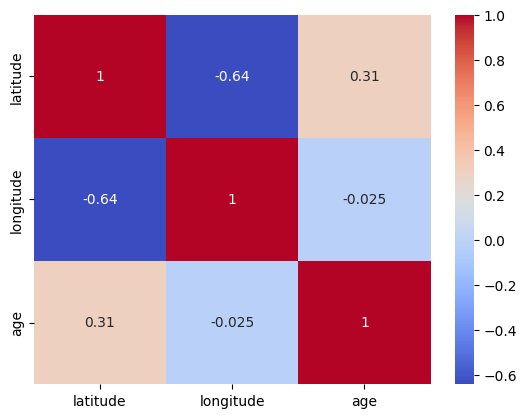

In [ ]:
sns.heatmap(fossil_data.corr(numeric_only=True), annot=True, cmap='coolwarm')

#### Is there any outliers in the data? What's the distribution of the data?

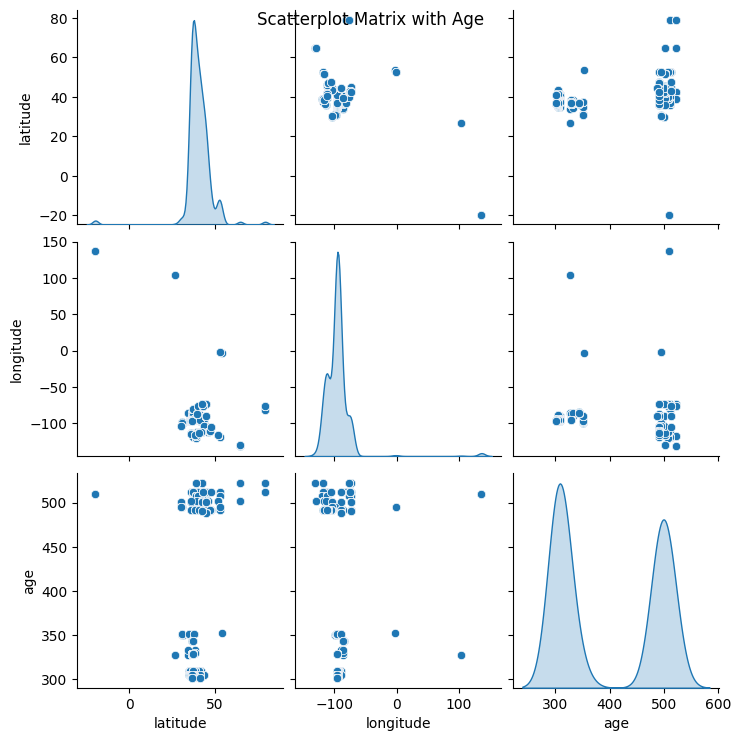

In [ ]:
sns.pairplot(fossil_data, diag_kind='kde') # diag_kind='kde' shows the distribution on the diagonal
plt.suptitle('Scatterplot Matrix with Age')
plt.show()

#### What other plots can we do?

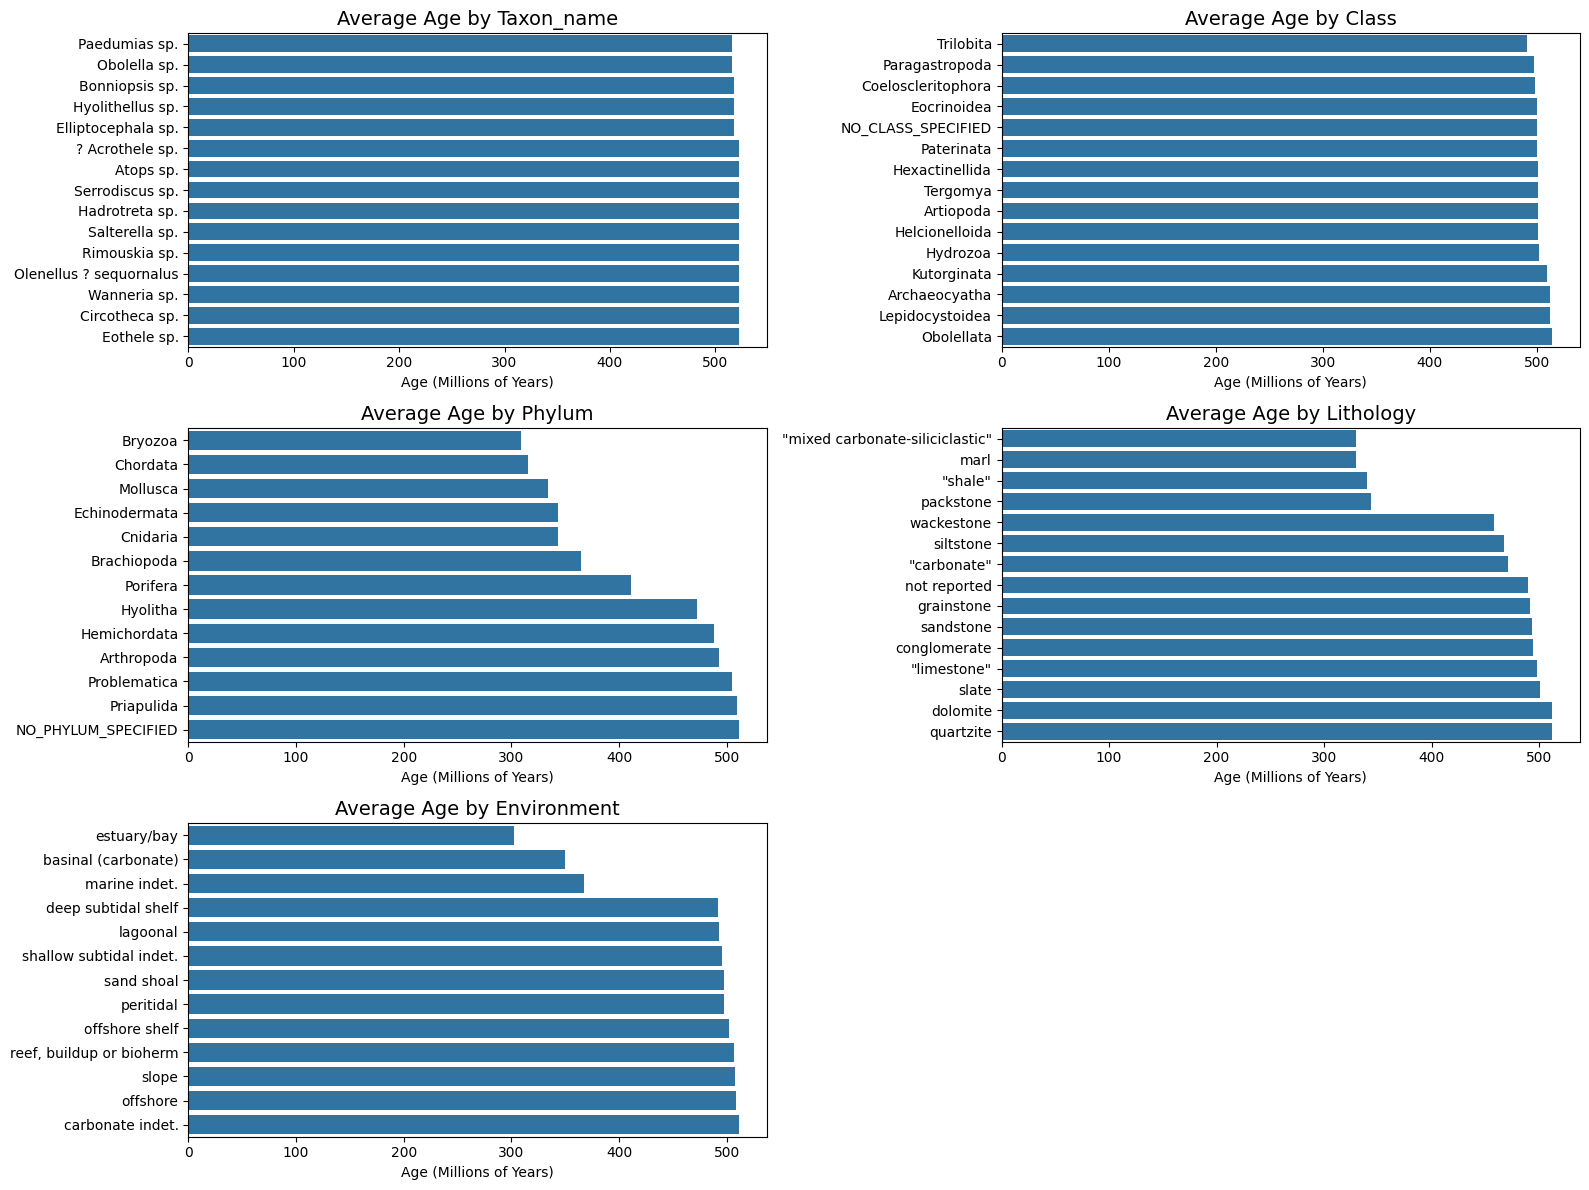

In [ ]:
# since we cant really do scatterplots, maybe we can do an alternative?

# group by categories and calculate the average age, then sort it
categories = ['taxon_name', 'class', 'phylum', 'lithology', 'environment']
avg_ages = {col: fossil_data.groupby(col)['age'].mean().sort_values() for col in categories}


fig, axes = plt.subplots(3, 2, figsize=(16, 12))
#flatten the 3x2 matrix of axes into a simple 1D list so we can loop through it
axes = axes.flatten()

# loop through our dictionary and plot each one
for i, (col, data) in enumerate(avg_ages.items()):

    # We take the top 15 oldest records to prevent the y-axis from becoming an unreadable wall of text
    # (Especially helpful for 'taxon_name' which likely has hundreds of unique values!)
    subset = data.dropna().tail(15)

    # Create a horizontal bar plot on the specific subplot axis (axes[i])
    sns.barplot(x=subset.values, y=subset.index, ax=axes[i])

    # Clean up the titles and labels
    axes[i].set_title(f'Average Age by {col.capitalize()}', fontsize=14)
    axes[i].set_xlabel('Age (Millions of Years)')
    axes[i].set_ylabel('')

fig.delaxes(axes[5])
plt.tight_layout() # so things dont overlap
plt.show()

### Data preprocessing

#### Any nulls?

In [ ]:
# Gives us information about the dataset (row count, column count, number of non-missing values)
# Important things to note: there are more than 100 records missing age values, and more than 600 missing Cabin values
fossil_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   taxon_name   2000 non-null   object 
 1   class        1880 non-null   object 
 2   phylum       2000 non-null   object 
 3   lithology    1993 non-null   object 
 4   environment  2000 non-null   object 
 5   latitude     2000 non-null   float64
 6   longitude    2000 non-null   float64
 7   age          2000 non-null   float64
dtypes: float64(3), object(5)
memory usage: 125.1+ KB


#### Fill nulls?

In [ ]:
fossil_data['class'] = fossil_data['class'].fillna(fossil_data['class'].mode()[0])
fossil_data['lithology'] = fossil_data['class'].fillna(fossil_data['class'].mode()[0])
fossil_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   taxon_name   2000 non-null   object 
 1   class        2000 non-null   object 
 2   phylum       2000 non-null   object 
 3   lithology    2000 non-null   object 
 4   environment  2000 non-null   object 
 5   latitude     2000 non-null   float64
 6   longitude    2000 non-null   float64
 7   age          2000 non-null   float64
dtypes: float64(3), object(5)
memory usage: 125.1+ KB


#### One-hot encoding

In [ ]:
fossil_data = pd.get_dummies(fossil_data, columns=['taxon_name', 'class', 'phylum', 'lithology', 'environment'], drop_first=True)

### Data Splitting & Scaling

In [ ]:
X = fossil_data.drop(columns=['age'])
y = fossil_data['age']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
# Fit the scaler ONLY on the training data, then transform it
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
fossil_data.shape

(2000, 724)

## End of Lab Part 1


## Models

### More Imports

In [ ]:
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input # updated

from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.model_selection import RandomizedSearchCV # new
from scipy.stats import uniform, randint # new
from sklearn.dummy import DummyRegressor # new

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


### What's the most simple model you can make? (Hint: it doesn't know any features about your data, only the raw age, y)

In [ ]:
baseline_model = DummyRegressor(strategy='mean')
baseline_model.fit(X_train, y_train) # calculates the average

y_pred_baseline = baseline_model.predict(X_test)

baseline_mse = mean_squared_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(baseline_mse)

print("Baseline Prediction (Mean Age):", y_pred_baseline[0])
print("Baseline MSE on Test Set:", baseline_mse)
print("Baseline RMSE on Test Set:", baseline_rmse)


Baseline Prediction (Mean Age): 395.69357187500003
Baseline MSE on Test Set: 9095.73548196415
Baseline RMSE on Test Set: 95.37156537440366


### Lasso Regression (The Lasso): Linear Regression + Performs automatic feature selection

In [ ]:
lasso = Lasso(alpha=1, random_state=42)

lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("Lasso Test MSE:", lasso_mse)
print("Lasso Test RMSE:", lasso_rmse)
print("Lasso Test R2:", lasso_r2)

Lasso Test MSE: 1133.3445882758494
Lasso Test RMSE: 33.665183621597095
Lasso Test R2: 0.8752546424088324


### XGBoost (Extreme Gradient Boosting): Boosting + Learning Rate

In [ ]:
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)

xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Test MSE:", xgb_mse)
print("XGBoost Test RMSE:", xgb_rmse)
print("XGBoost Test R2:", xgb_r2)

XGBoost Test MSE: 98.59083949336751
XGBoost Test RMSE: 9.929291993559637
XGBoost Test R2: 0.9891482699480451


### Neural Networks (its simulates a brain (kinda))

ReLU: An activation function which allows the layer to learn complex, highly irregular patterns in data.


Dropout: Randomly "turns off" a set percentage of neurons in a layer (e.g., 20% or 30%). Those dropped neurons temporarily stop receiving or passing on any information.


Batch Normalization: Keeps the distribution of data to be normal (even when fed into later layers). W/o this, the model could become unstable and be much slower when training in deeper layers.

In [ ]:
simple_nn = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

simple_nn.compile(optimizer='adam', loss='mse')

simple_history = simple_nn.fit(X_train_scaled, y_train,
                               epochs=100,
                               batch_size=32,
                               validation_split=0.2,
                               verbose=0)

y_pred_simple = simple_nn.predict(X_test_scaled).flatten()
simple_rmse = np.sqrt(mean_squared_error(y_test, y_pred_simple))


# complex neural network
complex_nn = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

complex_nn.compile(optimizer='adam', loss='mse')

complex_history = complex_nn.fit(X_train_scaled, y_train,
                                 epochs=150,
                                 batch_size=32,
                                 validation_split=0.2)

y_pred_complex = complex_nn.predict(X_test_scaled).flatten()
complex_rmse = np.sqrt(mean_squared_error(y_test, y_pred_complex))

print(f"Simple NN RMSE: {simple_rmse:.2f}")
print(f"Complex NN RMSE: {complex_rmse:.2f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Epoch 1/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 163513.4375 - val_loss: 169258.7969
Epoch 2/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 160987.5312 - val_loss: 162298.8594
Epoch 3/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 155596.5938 - val_loss: 140193.6406
Epoch 4/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 141646.7656 - val_loss: 103893.2031
Epoch 5/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 117383.0234 - val_loss: 70668.9219
Epoch 6/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 89249.8906 - val_loss: 51461.1875
Epoch 7/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 63138.6172 - val_loss: 41703.1562
Epoch 8/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 45058.5000 - val_loss: 37091.4492
Epoch 9/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 32033.8672 - val_loss: 33661.3086
Epoch 10/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 22040.8574 - val_loss: 26541.4121
Epoch 11/150
40/40 ━

### How good are the predictions?

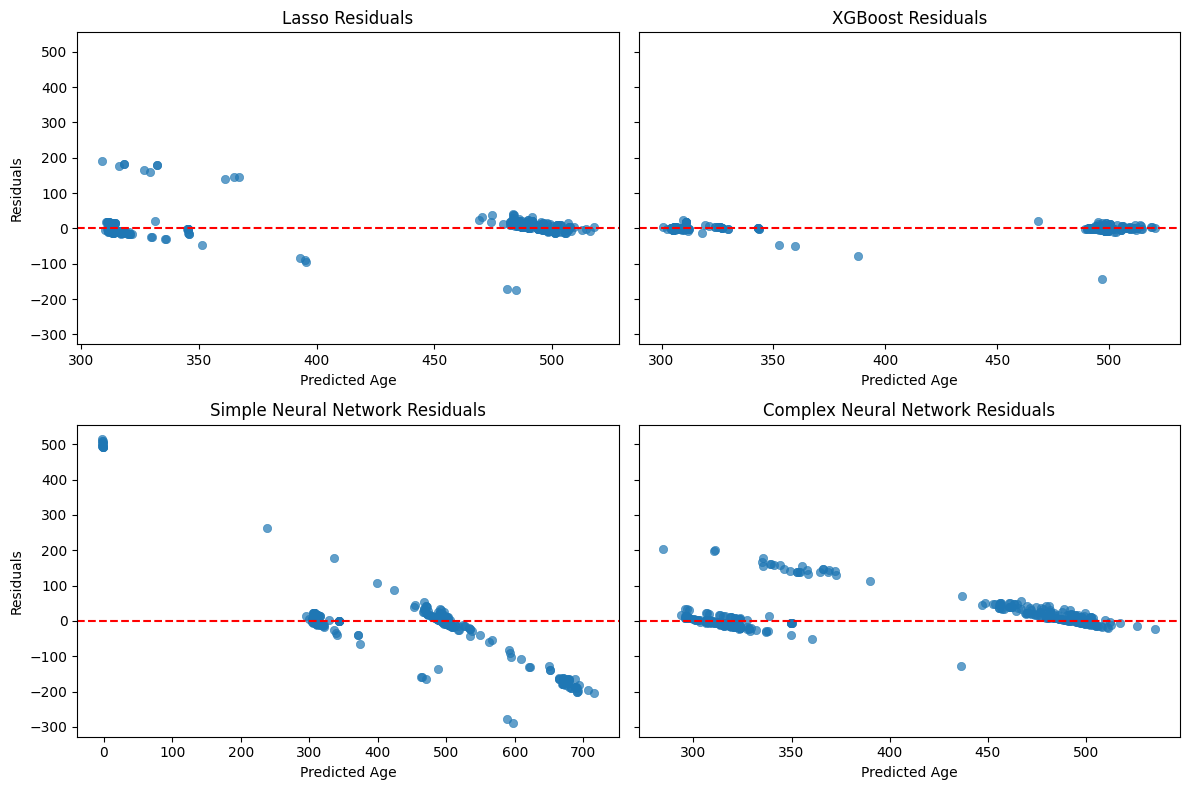

In [ ]:
res_lasso = y_test - y_pred_lasso
res_xgb = y_test - y_pred_xgb
res_simple_nn = y_test - y_pred_simple
res_complex_nn = y_test - y_pred_complex

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

# Lasso Residuals
sns.scatterplot(x=y_pred_lasso, y=res_lasso, ax=axes[0, 0], alpha=0.7, edgecolor=None)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Lasso Residuals')
axes[0, 0].set_xlabel('Predicted Age')
axes[0, 0].set_ylabel('Residuals')

# XGBoost Residuals
sns.scatterplot(x=y_pred_xgb, y=res_xgb, ax=axes[0, 1], alpha=0.7, edgecolor=None)
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title('XGBoost Residuals')
axes[0, 1].set_xlabel('Predicted Age')
axes[0, 1].set_ylabel('Residuals')

# Simple Neural Network Residuals
sns.scatterplot(x=y_pred_simple, y=res_simple_nn, ax=axes[1, 0], alpha=0.7, edgecolor=None)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_title('Simple Neural Network Residuals')
axes[1, 0].set_xlabel('Predicted Age')
axes[1, 0].set_ylabel('Residuals')

# Complex Neural Network Residuals
sns.scatterplot(x=y_pred_complex, y=res_complex_nn, ax=axes[1, 1], alpha=0.7, edgecolor=None)
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_title('Complex Neural Network Residuals')
axes[1, 1].set_xlabel('Predicted Age')
axes[1, 1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

# res = y_test - y_pred (high res implies too low of prediction)

### Lasso and XGBoost Feature Importance

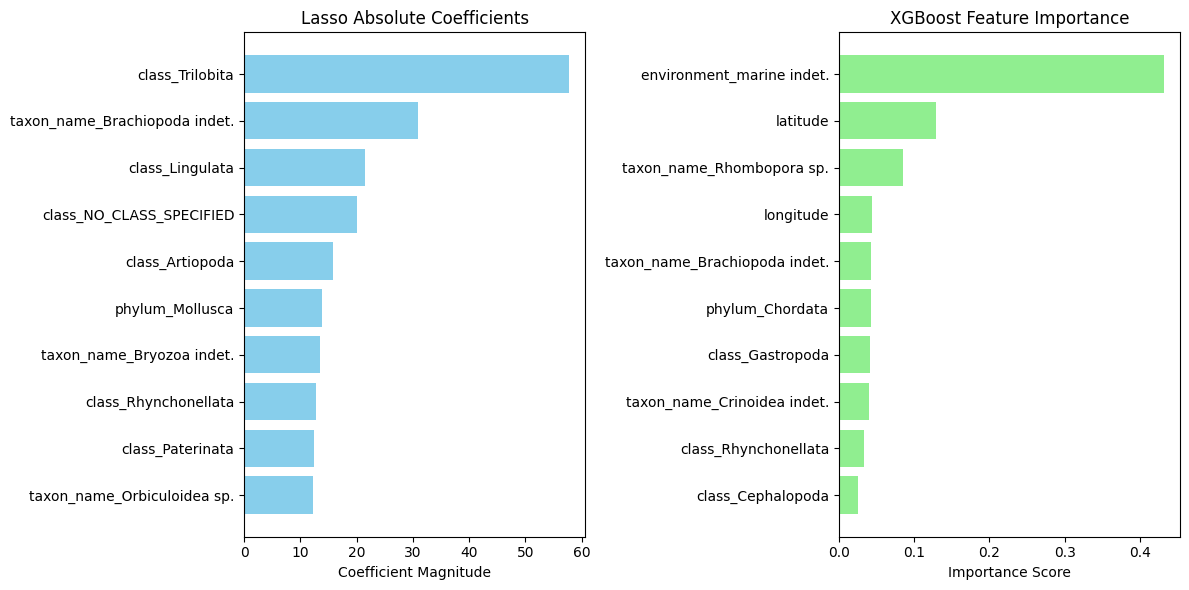

In [ ]:
lasso_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(lasso.coef_)
}).sort_values(by='Importance', ascending=True)

lasso_importance = lasso_importance.tail(10) # can adjust

xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=True)

top_10_xgb = xgb_importance.tail(10) # can adjust

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].barh(lasso_importance['Feature'], lasso_importance['Importance'], color='skyblue')
axes[0].set_title('Lasso Absolute Coefficients')
axes[0].set_xlabel('Coefficient Magnitude')

axes[1].barh(top_10_xgb['Feature'], top_10_xgb['Importance'], color='lightgreen')
axes[1].set_title('XGBoost Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

### Let's find the best lambda for Lasso

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.752e+04, tolerance: 1.437e+03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.747e+04, tolerance: 1.437e+03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.743e+04, tolerance: 1.437e

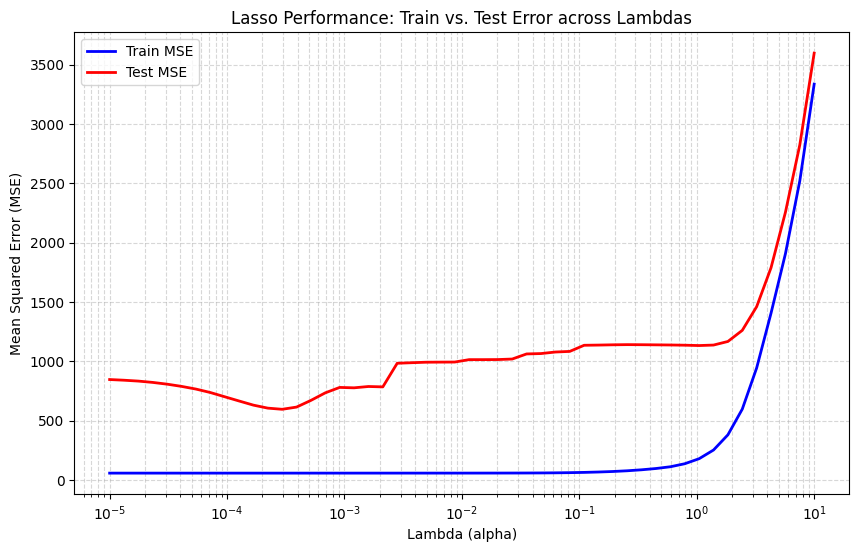

In [ ]:
lambdas = np.logspace(-5, 1, 50) # creates an array of exactly 50 numbers that are evenly spaced on a log scale #e^5 to e^2

train_errors = [] # track training error
test_errors = [] # track testing error

for lambda_ in lambdas:
    model = Lasso(alpha=lambda_, max_iter=10000, random_state=42)
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(lambdas, train_errors, label='Train MSE', color='blue', linewidth=2)
ax.plot(lambdas, test_errors, label='Test MSE', color='red', linewidth=2)

ax.set_xscale('log')
ax.set_xlabel('Lambda (alpha)')
ax.set_ylabel('Mean Squared Error (MSE)')
ax.set_title('Lasso Performance: Train vs. Test Error across Lambdas')
ax.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

In [ ]:
best_index = np.argmin(test_errors) # minimized

best_lambda = lambdas[best_index]
lowest_mse = test_errors[best_index]

print(f"The best lambda (alpha) is: {best_lambda:.6f}")
print(f"The lowest Test MSE achieved is: {lowest_mse:.2f}")
print(f"The lowest Test RMSE achieved is: {np.sqrt(lowest_mse):.2f}")

The best lambda (alpha) is: 0.000295
The lowest Test MSE achieved is: 595.78
The lowest Test RMSE achieved is: 24.41


### Hyperparameter Tuning for XGBoost

In [ ]:
xgb_hp_dist = {
    'n_estimators': randint(50, 300), # number of trees
    'learning_rate': uniform(0.01, 0.29), # how "fast" you want it to learn (too high is bad tho)
    'max_depth': randint(3, 10),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
}

xgb_random = RandomizedSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=42),
    param_distributions=xgb_hp_dist,
    n_iter=30,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42
)

xgb_random.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                        'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ec1ac79c3e0>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ec13414f5c0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ec12c759e80>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ec12c6586e0>},
                   random_state=42, scoring='neg_mean_squared_error')

In [ ]:
y_pred_xgb_tuned = xgb_random.predict(X_test_scaled)

xgb_tuned_mse = mean_squared_error(y_test, y_pred_xgb_tuned)
xgb_tuned_rmse = np.sqrt(xgb_tuned_mse)
xgb_tuned_r2 = r2_score(y_test, y_pred_xgb_tuned)

print("Tuned XGBoost Test MSE:", xgb_tuned_mse)
print("Tuned XGBoost Test RMSE:", xgb_tuned_rmse)
print("Tuned XGBoost Test R2:", xgb_tuned_r2)

print("\nBest Hyperparameters Found:")
xgb_random.best_params_

Tuned XGBoost Test MSE: 91.16114444261224
Tuned XGBoost Test RMSE: 9.547834542063045
Tuned XGBoost Test R2: 0.9899660441497199

Best Hyperparameters Found:


{'colsample_bytree': np.float64(0.7376851115910559),
 'learning_rate': np.float64(0.17334991587315127),
 'max_depth': 6,
 'n_estimators': 271,
 'subsample': np.float64(0.5696657272029378)}